# A股 Level2 Market Microstructure Study
## Topic: How does opening auction determine the first traded price?

### Objective
This notebook studies the A-share opening auction mechanism using Level2 data (qtick/qorder/qknock).

We focus on three key questions:

1. How does liquidity build up before 9:25?
2. How is the opening price determined at 9:25?
3. How does trading activity concentrate around auction time?

We use DolphinDB Level2 data and visualize market behavior during 9:15–9:30.

# What Can We Learn from Three Tables under `quota`?
qorder(trading intention) -> qknock(execution result) -> qtick(market state)

- trader submits order -> qorder
- orders interact -> qknock
- market updates -> qtick

## 1. qtick — Market State

**What is it?**

Market snapshot table describing the current state of the order book and prices.

### Key Fields

```text
time
bp0~bp9
ap0~ap9
bv0~bv9
av0~av9
new_price
open
pre_close
```

### What does it tell us?

- Where the market thinks the price is.
- Current bid/ask pressure.
- Market liquidity and depth.
- Auction price formation.

### Typical Analysis

- Price evolution during auction.
- Mid-price and spread.
- Order book imbalance.
- Liquidity buildup before 9:25.
- Opening price prediction.

> qtick answers:
>
> **"What does the market currently look like?"**

---

## 2. qorder — Trading Intention

**What is it?**

Order submission table describing what traders want to do.

### Key Fields

```text
time
bs_flag
order_type
order_price
order_volume
```

### What does it tell us?

- Buying vs selling intentions.
- Order arrival behavior.
- Market aggressiveness.
- Order imbalance.

### Typical Analysis

- Buy/sell order flow.
- Order imbalance.
- Large order behavior.
- Auction participation.
- Order arrival intensity.

> qorder answers:
>
> **"What does the market want to do?"**

---

## 3. qknock — Trade Execution

**What is it?**

Transaction table describing what actually traded.

### Key Fields

```text
time
trade_price
trade_volume
trade_amount
buy_order_no
sell_order_no
```

### What does it tell us?

- Actual execution prices.
- Executed volume.
- Trading activity.
- Market impact.

### Typical Analysis

- VWAP.
- Volume concentration.
- Trade intensity.
- Opening auction execution.
- Buyer/seller aggressiveness.

> qknock answers:
>
> **"What actually happened?"**

---

# Summary

| Table | Question |
|------|----------|
| qtick | What does the market look like? |
| qorder | What does the market want to do? |
| qknock | What actually happened? |


| 时间段       | 含义              | 行为                 |
| --------- | --------------- | ------------------ |
| 9:15–9:20 | early auction   | 撤单+试探报价            |
| 9:20–9:25 | locked phase    | 不可撤单 + 意愿聚集        |
| 9:24–9:25 | pre-close build | order imbalance 形成 |
| 9:25      | match           | auction price 形成   |
| 9:25–9:30 | stabilization   | 撮合后微调              |

In [81]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

In [82]:
from src.ddb_client import connect_ddb

s = connect_ddb()

df = s.run("""
select *
from loadTable("dfs://quota","qtick")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")


In [83]:
raw = df.copy()

raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["time"] = pd.to_datetime(raw["time"], errors="coerce")

raw = raw.dropna(subset=["date", "time"])

# 用 date + time-of-day 重新合成真正的 datetime，避免 x 轴变成 1970
raw["datetime"] = raw.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

raw = raw.sort_values(["date", "datetime"]).reset_index(drop=True)

## Data Description

We use Level2 snapshot data (qtick), which contains:
- Best bid/ask prices (bp0/ap0)
- Trade price (new_price)
- Order book depth (bv0-av9)

We restrict analysis to the opening auction period (9:15–9:30).

In [84]:
# standardize time column to datetime and sort the dataframe by time
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# 9:15-9:30
df = df[
    (df["time"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (df["time"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

In [85]:
# clean invalid trades
df = df[df["new_price"] > 0].copy()

df = df.drop_duplicates(subset=["time", "new_price"])

## Market Variables

We construct three key variables:

- Mid Price: market expectation
- Trade Price: execution price
- Spread: liquidity tightness

In [86]:
df["mid_price"] = (df["bp0"] + df["ap0"]) / 2
df["trade_price"] = df["new_price"]
df["spread"] = df["ap0"] - df["bp0"]

In [87]:
# microprice (IMPORTANT UPGRADE)
df["microprice"] = (
    df["bp0"] * df["av0"] + df["ap0"] * df["bv0"]
) / (df["bv0"] + df["av0"] + 1e-9)

# depth
df["bid_vol"] = df[[f"bv{i}" for i in range(10)]].sum(axis=1)
df["ask_vol"] = df[[f"av{i}" for i in range(10)]].sum(axis=1)

# imbalance (KEY VARIABLE)
df["imbalance"] = (df["bid_vol"] - df["ask_vol"]) / (df["bid_vol"] + df["ask_vol"] + 1e-9)

### 交易时间轴图

Hypothesis:
> During the opening auction, market prices converge from noisy quotes to a single clearing price at 9:25.

We test whether trade prices converge to mid-price and stabilize around auction time.

In [88]:
def label_phase(t):
    t = t.time()
    if t < pd.to_datetime("09:20:00").time():
        return "9:15-9:20 (Order Submission)"
    elif t < pd.to_datetime("09:25:00").time():
        return "9:20-9:25 (Order Matching Build-up)"
    else:
        return "9:25-9:30 (Opening Auction Fix)"

df["phase"] = df["time"].apply(label_phase)

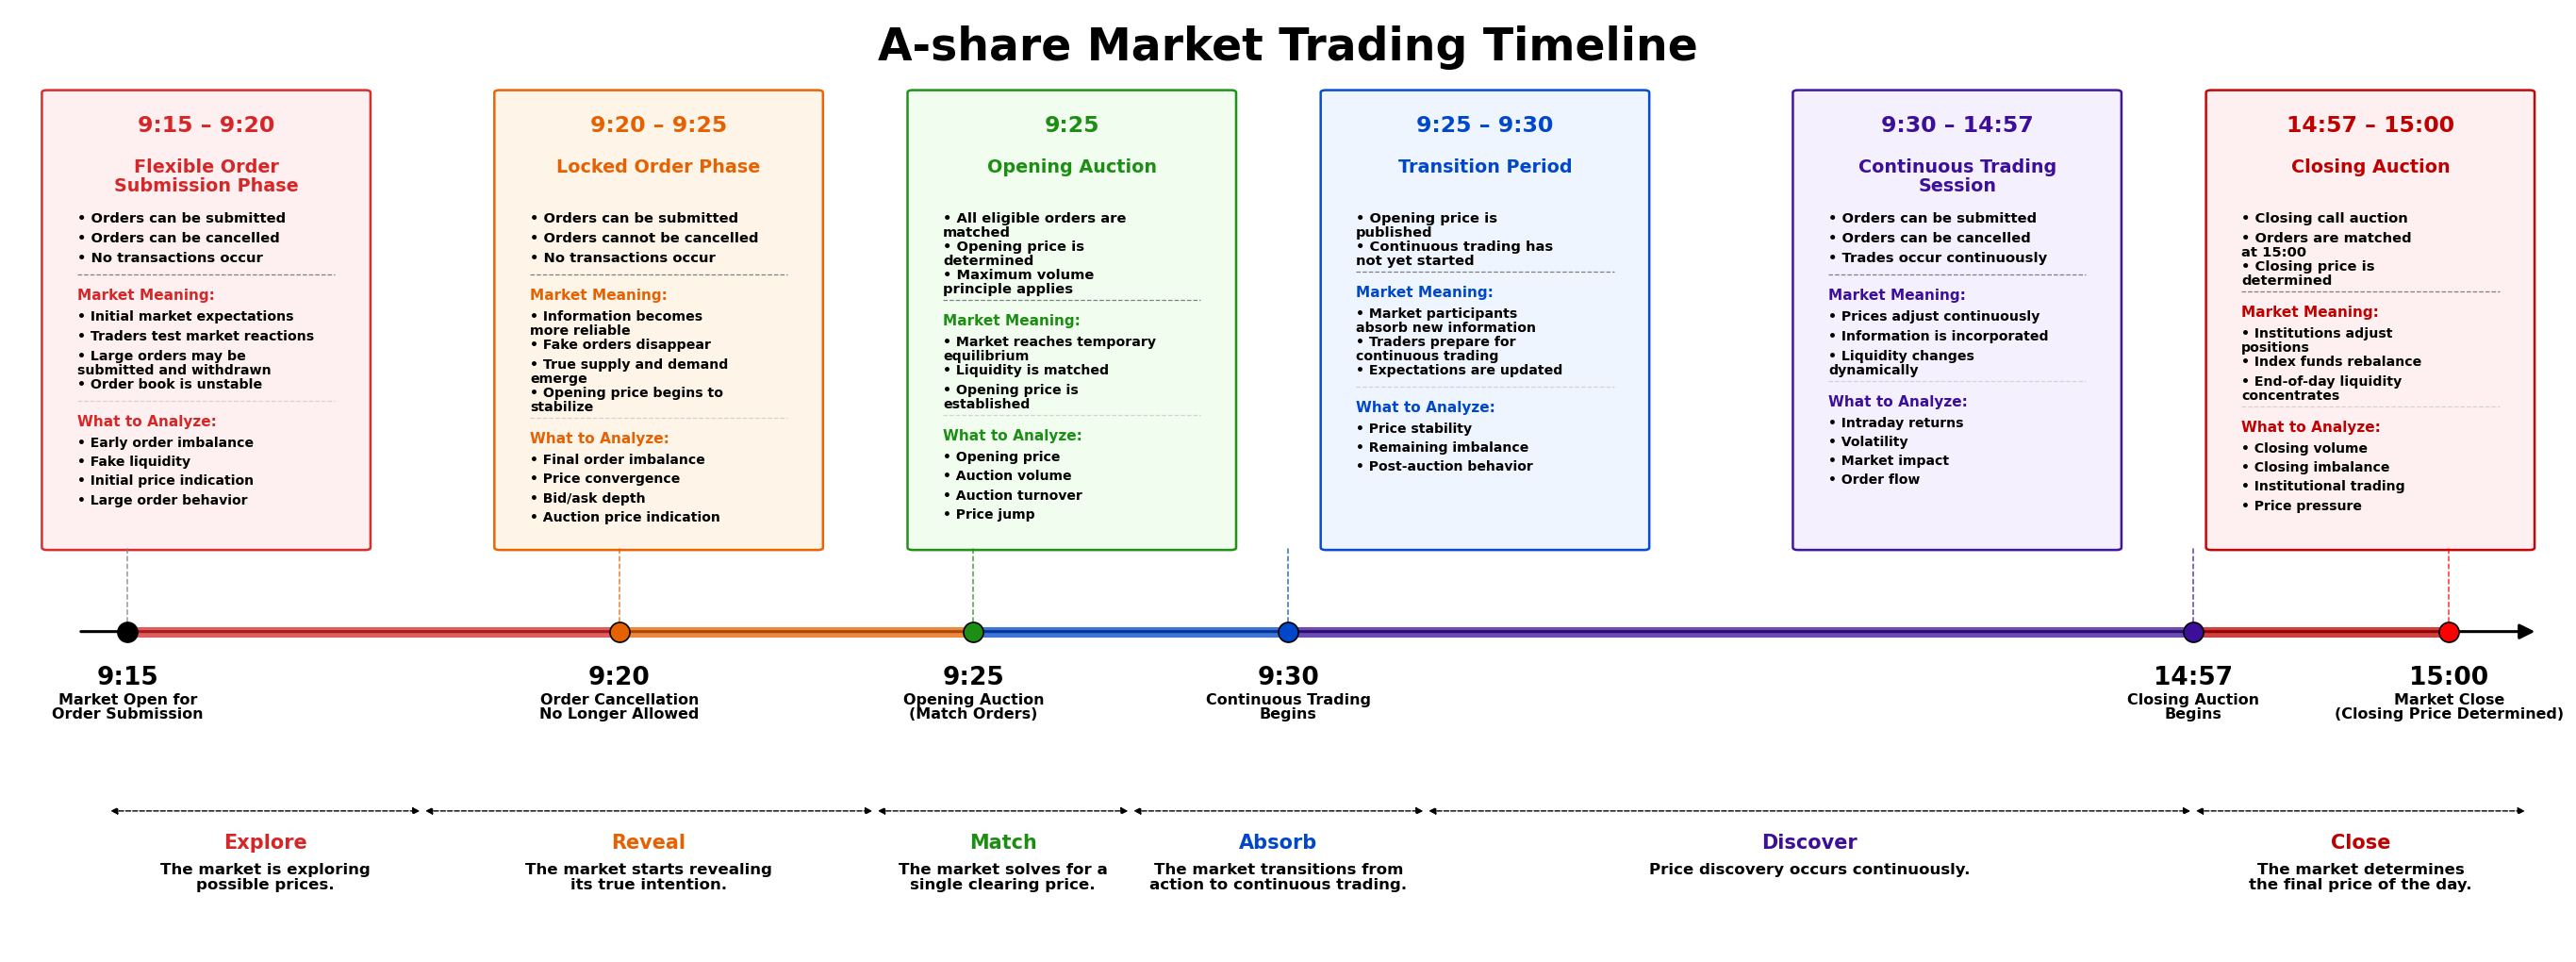

In [89]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(35, 13))
ax.set_xlim(0, 130)
ax.set_ylim(0, 100)
ax.axis("off")

# ---------- Title ----------
ax.text(
    65, 96,
    "A-share Market Trading Timeline",
    ha="center", va="center",
    fontsize=34,  
    fontweight="bold"
)

# ---------- Colors ----------
colors = {
    "explore": "#d62728",
    "reveal": "#e66101",
    "match": "#1b8e13",
    "absorb": "#0047cc",
    "discover": "#3b0f99",
    "close": "#c00000",
}

light_colors = {
    "explore": "#fff1f1",
    "reveal": "#fff6e8",
    "match": "#f2fff0",
    "absorb": "#f0f6ff",
    "discover": "#f6f1ff",
    "close": "#fff1f1",
}

def draw_card(card):
    x, y, w, h = card["x"], card["y"], card["w"], card["h"]
    key = card["key"]
    c = colors[key]

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.35,rounding_size=0.25",
        linewidth=1.8,
        edgecolor=c,
        facecolor=light_colors[key],
        alpha=0.97
    )
    box.set_path_effects([
        pe.SimplePatchShadow(offset=(1.2, -1.2), alpha=0.10),
        pe.Normal()
    ])
    ax.add_patch(box)

    cx = x + w / 2
    text_x = x + 1.45

    ax.text(cx, y + h - 2.2, card["time"],
            ha="center", va="top", fontsize=17,
            fontweight="bold", color=c)

    ax.text(cx, y + h - 6.8, card["title"],
            ha="center", va="top", fontsize=13.8,
            fontweight="bold", color=c, linespacing=1.05)

    yy = y + h - 12.5

    for b in card["bullets"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.6,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="gray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "Market Meaning:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["meaning"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.2,
                fontweight="bold", color="black", linespacing=1.05)
        yy -= 3.0 if "\n" in b else 2.1

    ax.plot([x + 1.45, x + w - 1.45], [yy - 0.35, yy - 0.35],
            linestyle="--", color="lightgray", linewidth=0.9)
    yy -= 1.8

    ax.text(text_x, yy, "What to Analyze:",
            ha="left", va="top", fontsize=11,
            fontweight="bold", color=c)
    yy -= 2.3

    for b in card["analyze"]:
        ax.text(text_x, yy, "• " + b,
                ha="left", va="top", fontsize=10.1,
                fontweight="bold", color="black")
        yy -= 2.0

for card in cards:
    draw_card(card)

for t, c, label in node_info:
    x = pos[t]

    ax.scatter(x, y_line, s=230, color=c, edgecolor="black", linewidth=1.2, zorder=5)

    ax.plot([x, x], [y_line + 1.0, card_y],
            linestyle="--", linewidth=1.1,
            color=c if c != "black" else "gray", alpha=0.8)

    # 时间节点
    ax.text(x, y_line - 3.5, t,
            ha="center", va="top", fontsize=19,  
            fontweight="bold", color="black")

    # 节点描述
    ax.text(x, y_line - 6.4, label,
            ha="center", va="top", fontsize=11.5, 
            fontweight="bold", color="black", linespacing=1.05)

# ---------- Main timeline ----------
segments = [
    ("9:15", "9:20", "explore"),
    ("9:20", "9:25", "reveal"),
    ("9:25", "9:30", "absorb"),
    ("9:30", "14:57", "discover"),
    ("14:57", "15:00", "close"),
]

ax.add_patch(FancyArrowPatch(
    (pos["9:15"] - 2.5, y_line), (128.5, y_line),
    arrowstyle="-|>", mutation_scale=24,
    linewidth=2.2, color="black"
))

for start, end, key in segments:
    ax.plot(
        [pos[start], pos[end]],
        [y_line, y_line],
        color=colors[key],
        linewidth=8,
        solid_capstyle="round",
        alpha=0.75
    )

node_info = [
    ("9:15", "black", "Market Open for\nOrder Submission"),
    ("9:20", colors["reveal"], "Order Cancellation\nNo Longer Allowed"),
    ("9:25", colors["match"], "Opening Auction\n(Match Orders)"),
    ("9:30", colors["absorb"], "Continuous Trading\nBegins"),
    ("14:57", colors["discover"], "Closing Auction\nBegins"),
    ("15:00", "red", "Market Close\n(Closing Price Determined)"),
]

function_ranges = [
    (5, 21, "Explore", "The market is exploring\npossible prices.", "explore"),
    (21, 44, "Reveal", "The market starts revealing\nits true intention.", "reveal"),
    (44, 57, "Match", "The market solves for a\nsingle clearing price.", "match"),
    (57, 72, "Absorb", "The market transitions from\naction to continuous trading.", "absorb"),
    (72, 111, "Discover", "Price discovery occurs continuously.", "discover"),
    (111, 128, "Close", "The market determines\nthe final price of the day.", "close"),
]

for x1, x2, title, desc, key in function_ranges:
    ax.add_patch(FancyArrowPatch(
        (x1, y_arrow), (x2, y_arrow),
        arrowstyle="<|-|>",
        mutation_scale=11,
        linewidth=1.0,
        linestyle="--",
        color="black"
    ))

    # 底部功能标题
    ax.text((x1 + x2) / 2, y_arrow - 2.3, title,
            ha="center", va="top", fontsize=15, 
            fontweight="bold", color=colors[key])

    # 底部功能描述
    ax.text((x1 + x2) / 2, y_arrow - 5.4, desc,
            ha="center", va="top", fontsize=12, 
            fontweight="bold", color="black", linespacing=1.05)

## Single-Stock Case Study

### 样例股票集合竞价价格变化图

In [90]:
auction = raw[
    (raw["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (raw["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

# 数值字段清洗
price_cols = ["bp0", "ap0", "new_price", "pre_close", "open"]

for col in price_cols:
    if col in auction.columns:
        auction[col] = pd.to_numeric(auction[col], errors="coerce")

# qtick 盘口参考价格：不要依赖 new_price
auction["mid_price"] = (auction["bp0"] + auction["ap0"]) / 2
auction.loc[auction["mid_price"] <= 0, "mid_price"] = np.nan

# 有效成交价，仅用于散点
auction["trade_price"] = auction["new_price"]
auction.loc[auction["trade_price"] <= 0, "trade_price"] = np.nan

# 相对昨收涨跌幅
auction.loc[auction["pre_close"] <= 0, "pre_close"] = np.nan
auction["auction_ret"] = auction["mid_price"] / auction["pre_close"] - 1

print("Trading days:", auction["date"].nunique())
print("Rows:", len(auction))

Trading days: 22
Rows: 871


In [91]:
# 选有效 mid_price 最多的一天作为样例日
day_counts = auction.groupby("date")["mid_price"].count().sort_values(ascending=False)
example_day = day_counts.index[0]

one_day = auction[auction["date"] == example_day].copy()

print("Example day:", example_day.date())
print("Valid mid price ticks:", one_day["mid_price"].notna().sum())
print("Valid trade ticks:", one_day["trade_price"].notna().sum())

Example day: 2026-03-16
Valid mid price ticks: 65
Valid trade ticks: 2


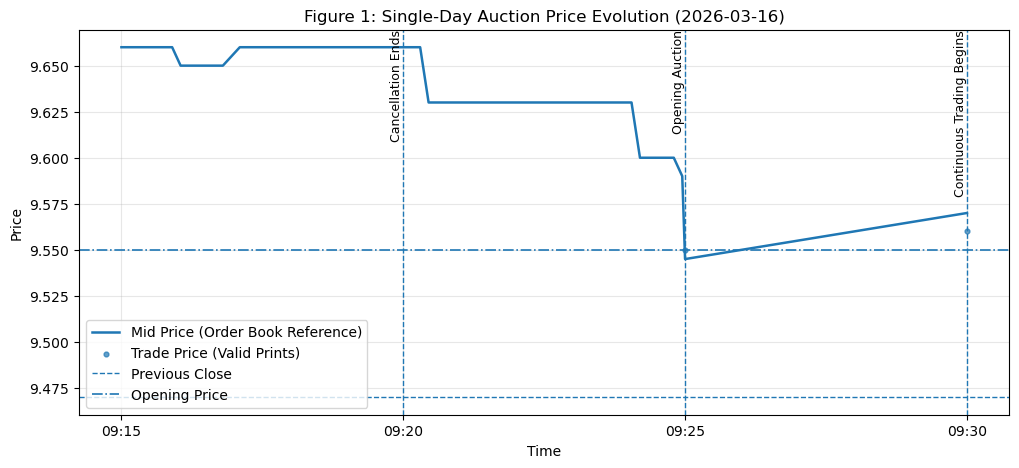

In [92]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day["datetime"],
    one_day["mid_price"],
    label="Mid Price (Order Book Reference)",
    linewidth=1.8
)

ax.scatter(
    one_day["datetime"],
    one_day["trade_price"],
    s=12,
    alpha=0.7,
    label="Trade Price (Valid Prints)"
)

# 昨收与开盘价
prev_close = one_day["pre_close"].dropna().iloc[0] if one_day["pre_close"].notna().any() else None
open_price = one_day["open"].dropna().iloc[-1] if "open" in one_day.columns and one_day["open"].notna().any() else None

if prev_close is not None:
    ax.axhline(prev_close, linestyle="--", linewidth=1, label="Previous Close")

if open_price is not None and open_price > 0:
    ax.axhline(open_price, linestyle="-.", linewidth=1.2, label="Opening Price")

# 关键时间节点
for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.Timestamp.combine(example_day.date(), pd.to_datetime(t).time())
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title(f"Figure 1: Single-Day Auction Price Evolution ({example_day.date()})")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

- 9：15-9：20：价格在9.65，9.66附近震荡，说明买卖双已经有共识，价格并没有乱跳
- 9：20-9：25：价格开始下降，从9.63到9.60到9.59，说明市场真是卖压出现，因为不能撤单
- 9：25时：价格突然掉到9.545，且opening price ≈ previous close，可暂时说明前面的盘口价格可能偏乐观，在真正order成交后, equilibrium price lower.

In [93]:
# 把每天对齐到统一 10 秒时间网格
def align_one_day(g, freq="10s"):
    current_date = g["date"].iloc[0]
    
    start = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:15:00").time())
    end = pd.Timestamp.combine(current_date.date(), pd.to_datetime("09:30:00").time())
    grid = pd.date_range(start=start, end=end, freq=freq)
    
    temp = g.sort_values("datetime").set_index("datetime")
    
    aligned = temp[["auction_ret"]].reindex(grid, method="ffill")
    aligned["auction_ret"] = aligned["auction_ret"].bfill()
    
    aligned["date"] = current_date
    aligned["clock_time"] = aligned.index.strftime("%H:%M:%S")
    
    return aligned.reset_index(drop=True)

aligned_list = []

for d, g in auction.groupby("date"):
    if g["auction_ret"].notna().sum() >= 5:
        aligned_list.append(align_one_day(g, freq="10s"))

aligned = pd.concat(aligned_list, ignore_index=True)

ret_matrix = aligned.pivot(
    index="clock_time",
    columns="date",
    values="auction_ret"
).sort_index()

mean_path = ret_matrix.mean(axis=1)
std_path = ret_matrix.std(axis=1)

plot_times = pd.to_datetime(ret_matrix.index, format="%H:%M:%S")

print("Aligned days:", ret_matrix.shape[1])
print("Time points:", ret_matrix.shape[0])

Aligned days: 22
Time points: 91


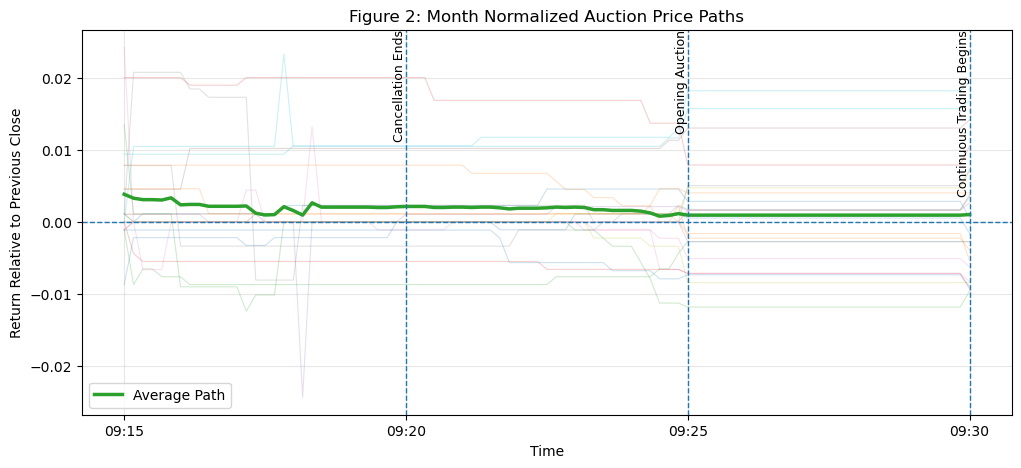

In [94]:
fig, ax = plt.subplots(figsize=(12, 5))

# 每天一条浅线
for col in ret_matrix.columns:
    ax.plot(
        plot_times,
        ret_matrix[col],
        alpha=0.22,
        linewidth=0.8
    )

# 平均路径
ax.plot(
    plot_times,
    mean_path,
    linewidth=2.5,
    label="Average Path"
)

ax.axhline(0, linestyle="--", linewidth=1)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 2: Month Normalized Auction Price Paths")
ax.set_xlabel("Time")
ax.set_ylabel("Return Relative to Previous Close")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这张表将一个月交易日的数据整合在一起并平均路径，发现仍是竞价初期偏乐观后市场逐渐修正，符合case抽样的价格变化趋势。

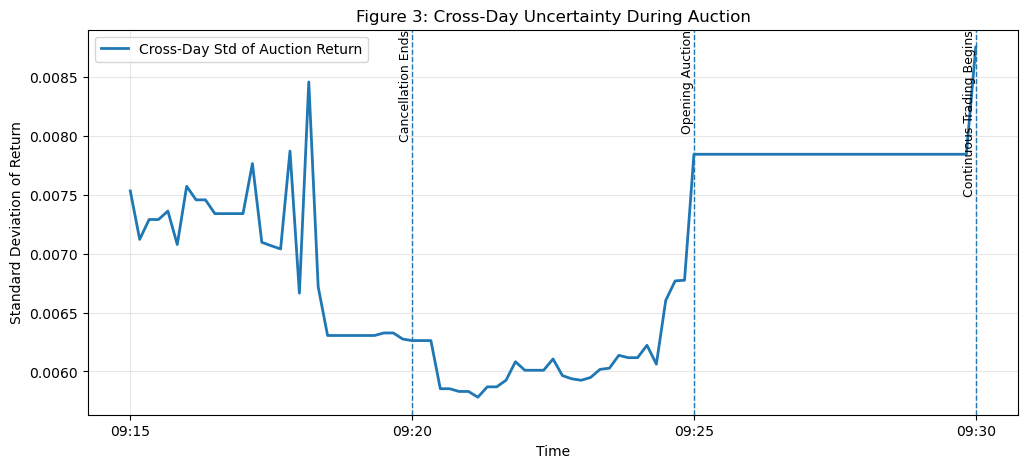

In [95]:
# 每个时刻的跨天标准差
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    std_path,
    linewidth=2,
    label="Cross-Day Std of Auction Return"
)

for t, label in [
    ("09:20:00", "Cancellation Ends"),
    ("09:25:00", "Opening Auction"),
    ("09:30:00", "Continuous Trading Begins")
]:
    x = pd.to_datetime(t, format="%H:%M:%S")
    ax.axvline(x, linestyle="--", linewidth=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)

ax.set_title("Figure 3: Cross-Day Uncertainty During Auction")
ax.set_xlabel("Time")
ax.set_ylabel("Standard Deviation of Return")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

为了比较不同交易日集合竞价阶段价格信号的稳定程度，首先对所有交易日进行了时间对齐和价格标准化。
1. 价格标准化：对于每个交易日，定义 auction_return = mid_price/pre_close-1. 将盘口参考价格转换为相对昨收的涨跌幅，这样不同价格水平的股票可以放到同一尺度进行比较。
2. 时间对齐：由于qtick不是严格固定时间间隔产生，因此每天的快照时间点不同且有些时间点存在缺失。因此，我将所有交易日时间统一10s一取样
3. 计算标准差：通过计算standard deviation, 了解同一时刻，不同交易日之间价格信号的离散程度

x-axis:
Auction time (09:15–09:30)

y-axis:
Cross-day standard deviation of auction returns

第一阶段9：15-9：20：std比较高，再0.0072到0.0085附近摆动，说明不同交易日价格路径差距较大，市场预期尚未稳定，且价格信号具有较强noise
第二阶段9：20-9：25：std明显下降到0.0058附近，说明由于不能cancel order，市场价格开始收敛，不同交易日之间的价格分歧减弱且信息质量提高
第三阶段9：25后：std重新上升，可能原因有：开盘价存在跨日差异，高开于低开导致收益率std扩大，也有数据对齐方法带来的影响

### 委托量变化图

In [96]:
qorder = s.run("""
select *
from loadTable("dfs://quota","qorder")
where code = "000009.SZ"
and date >= 2026.03.11
and date <= 2026.04.10
""")

In [97]:
# 1. Basic Cleaning

order = qorder.copy()

order["date"] = pd.to_datetime(order["date"], errors="coerce")
order["time"] = pd.to_datetime(order["time"], errors="coerce")

order = order.dropna(subset=["date", "time"])

order["datetime"] = order.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

order = order.sort_values(["date", "datetime"]).reset_index(drop=True)

# opening auction window
order = order[
    (order["datetime"].dt.time >= pd.to_datetime("09:15:00").time()) &
    (order["datetime"].dt.time <= pd.to_datetime("09:30:00").time())
].copy()

order["order_volume"] = pd.to_numeric(order["order_volume"], errors="coerce").fillna(0)

# classify buy/sell
# 根据你打印结果：bs_flag = 1 是 buy, 2 是 sell
order["side"] = np.where(
    order["bs_flag"] == 1,
    "buy",
    np.where(order["bs_flag"] == 2, "sell", "unknown")
)

order = order[order["side"].isin(["buy", "sell"])].copy()

print("Trading days:", order["date"].nunique())
print("Rows:", len(order))
print(order["side"].value_counts())
print(order[["bs_flag", "side", "order_type"]].drop_duplicates())

Trading days: 22
Rows: 20839
side
sell    14130
buy      6709
Name: count, dtype: int64
   bs_flag  side  order_type
0        2  sell           0
2        1   buy           0


In [98]:
# 2. Aggregate to 10-second grid
order["clock_time"] = order["datetime"].dt.floor("10s").dt.strftime("%H:%M:%S")

agg = (
    order
    .groupby(["date", "clock_time", "side"])["order_volume"]
    .sum()
    .reset_index()
)

pivot = agg.pivot_table(
    index=["date", "clock_time"],
    columns="side",
    values="order_volume",
    fill_value=0
).reset_index()

if "buy" not in pivot.columns:
    pivot["buy"] = 0

if "sell" not in pivot.columns:
    pivot["sell"] = 0

pivot["total_order_volume"] = pivot["buy"] + pivot["sell"]

pivot["order_imbalance"] = np.where(
    pivot["total_order_volume"] > 0,
    (pivot["buy"] - pivot["sell"]) / pivot["total_order_volume"],
    np.nan
)

# average across all trading days
month_avg = (
    pivot
    .groupby("clock_time")[["buy", "sell", "total_order_volume", "order_imbalance"]]
    .mean()
    .reset_index()
)

plot_times = pd.to_datetime(month_avg["clock_time"], format="%H:%M:%S")

print("Valid clock points:", len(month_avg))

Valid clock points: 61


In [99]:
def add_auction_markers(ax):
    for t, label in [
        ("09:20:00", "Cancellation Ends"),
        ("09:25:00", "Opening Auction"),
        ("09:30:00", "Continuous Trading Begins")
    ]:
        x = pd.to_datetime(t, format="%H:%M:%S")
        ax.axvline(x, linestyle="--", linewidth=1)
        ax.text(
            x,
            ax.get_ylim()[1],
            label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=9
        )

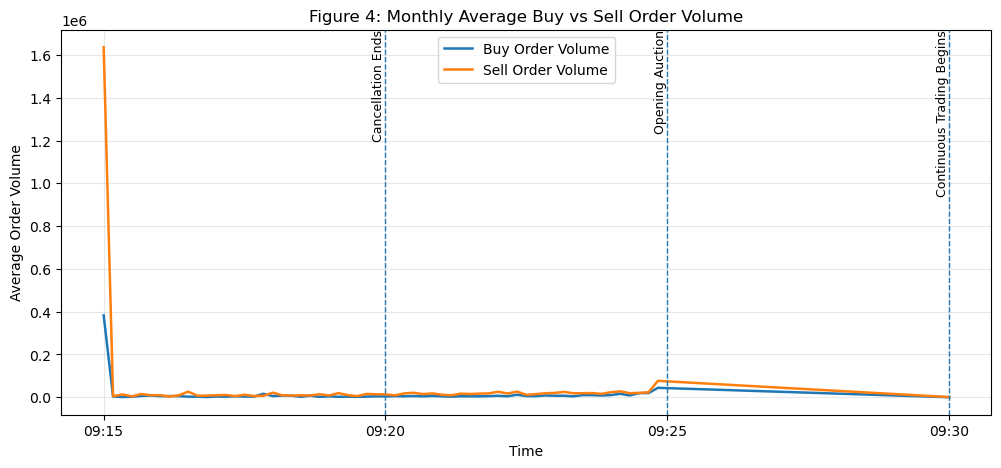

In [100]:
# Figure 4: Monthly Average Buy vs Sell Order Volume
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["buy"],
    label="Buy Order Volume",
    linewidth=1.8
)

ax.plot(
    plot_times,
    month_avg["sell"],
    label="Sell Order Volume",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 4: Monthly Average Buy vs Sell Order Volume")
ax.set_xlabel("Time")
ax.set_ylabel("Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

9：15：出现巨大峰值，可能因为集合竞价开始，大量隔夜订单进入，卖单一次性释放且整体股票偏空
9：15后：买卖量都很小，因为是逐笔委托，真正的新增订单没盘口那么连续
9：25-9：25：出现了第二次放量，说明临近开盘，投资者重新调整

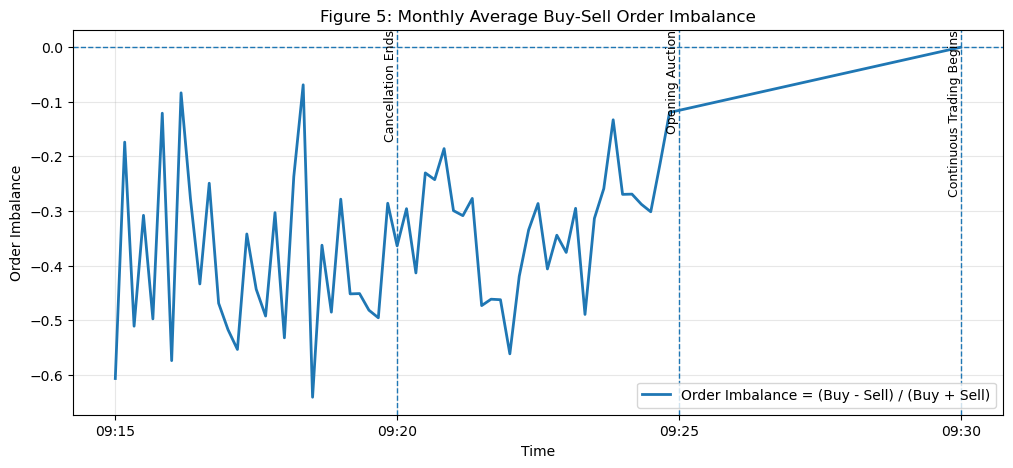

In [101]:
# Figure 5: Monthly Average Buy-Sell Order Imbalance

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_times,
    month_avg["order_imbalance"],
    label="Order Imbalance = (Buy - Sell) / (Buy + Sell)",
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

add_auction_markers(ax)

ax.set_title("Figure 5: Monthly Average Buy-Sell Order Imbalance")
ax.set_xlabel("Time")
ax.set_ylabel("Order Imbalance")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

因为全部小于0，说明整个月卖方持续占优。且从9：15-9：20的-0.4到9：24的-0.1，这说明卖压在减弱，买卖开始趋于平衡，与qtick的验证匹配。

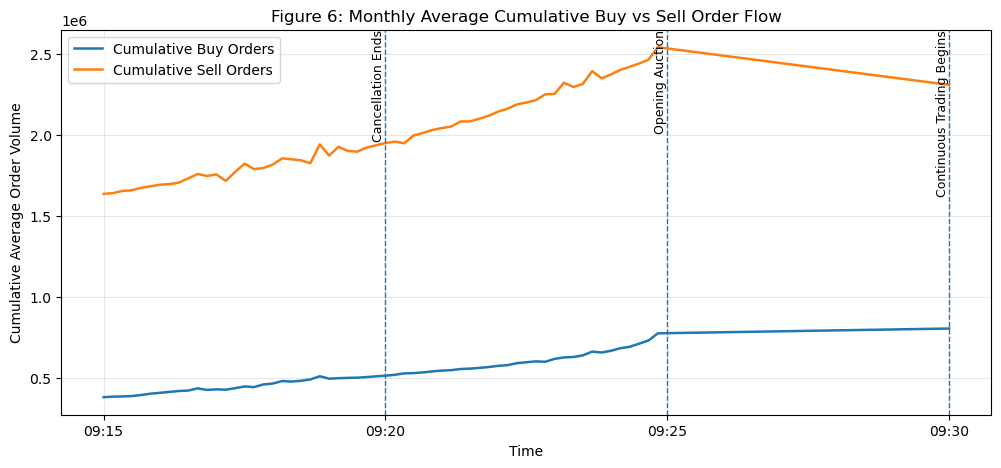

In [102]:
# Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow
pivot = pivot.sort_values(["date", "clock_time"]).copy()

pivot["cum_buy"] = pivot.groupby("date")["buy"].cumsum()
pivot["cum_sell"] = pivot.groupby("date")["sell"].cumsum()
pivot["cum_net"] = pivot["cum_buy"] - pivot["cum_sell"]

cum_avg = (
    pivot
    .groupby("clock_time")[["cum_buy", "cum_sell", "cum_net"]]
    .mean()
    .reset_index()
)

cum_times = pd.to_datetime(cum_avg["clock_time"], format="%H:%M:%S")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    cum_times,
    cum_avg["cum_buy"],
    label="Cumulative Buy Orders",
    linewidth=1.8
)

ax.plot(
    cum_times,
    cum_avg["cum_sell"],
    label="Cumulative Sell Orders",
    linewidth=1.8
)

add_auction_markers(ax)

ax.set_title("Figure 6: Monthly Average Cumulative Buy vs Sell Order Flow")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Average Order Volume")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.show()

这是累计的买卖单，说明整个竞价期间，卖方意愿要明显高于买方。9：25之前，卖单快速增加，这也说明了价格从9.66降到开盘价9.55原因。

## Multi-Stock Comparison

由于qtick在9：15-9：25提供信息的只有深交所的股票，这里先运用深交所的股票。

深交所内部大致可以这样分：
- 000 / 001 / 002 / 003 开头：深市主板 main_board
- 300 / 301 开头：创业板 chinext
- 200 开头：深市 B 股，一般先不要分析 exclude

eg. 000001.SZ 平安银行     深市主板
000858.SZ 五粮液       深市主板
002594.SZ 比亚迪       深市主板/原中小板
300750.SZ 宁德时代     创业板
300760.SZ 迈瑞医疗     创业板

In [110]:
import pandas as pd
from src.ddb_client import connect_ddb

s = connect_ddb()

In [112]:
sql = """
select distinct code
from loadTable("dfs://quota","qtick")
where date = 2026.03.11
"""

codes = s.run(sql)

codes.head()

,code
0,000001.SH
1,000015.SH
2,000017.SZ
3,000018.SH
4,000020.SZ


In [113]:
sz_codes = codes[
    codes["code"].str.endswith(".SZ")
].copy()

print(len(sz_codes))

22710


In [114]:
# 股票池如何
def board(code):

    if code.startswith(("000","001","002","003")):
        return "main"

    elif code.startswith(("300","301")):
        return "chinext"

    else:
        return "other"

sz_codes["board"] = sz_codes["code"].apply(board)

sz_codes["board"].value_counts()

board
other      19827
main        1491
chinext     1392
Name: count, dtype: int64

In [120]:
main_pool = sz_codes[sz_codes["board"] == "main"]
chinext_pool = sz_codes[sz_codes["board"] == "chinext"]

main_sample = main_pool.sample(
    n=min(30, len(main_pool)),
    random_state=42
)

chinext_sample = chinext_pool.sample(
    n=min(20, len(chinext_pool)),
    random_state=42
)

stock_pool = pd.concat(
    [main_sample, chinext_sample],
    ignore_index=True
)

sample_codes = stock_pool["code"].tolist()

print("Selected stocks:", len(sample_codes))
print(stock_pool["board"].value_counts())
print(sample_codes[:10])

Selected stocks: 50
board
main       30
chinext    20
Name: count, dtype: int64
['000950.SZ', '000155.SZ', '002713.SZ', '000010.SZ', '002708.SZ', '002015.SZ', '002777.SZ', '001288.SZ', '002292.SZ', '002655.SZ']


In [121]:
codes_str = ",".join(
    [f'"{c}"' for c in sample_codes]
)

sql = f"""
select *
from loadTable("dfs://quota","qtick")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in ({codes_str})
  and time >= 09:15:00.000
  and time <= 09:30:00.000  
"""

qtick_50 = s.run(sql)

qtick_50.head()

,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,300768.SZ,2026-03-11,1970-01-01 09:15:00,0,0,18.55,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,300768.SZ,2026-03-11,1970-01-01 09:15:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,300768.SZ,2026-03-11,1970-01-01 09:16:12,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,300768.SZ,2026-03-11,1970-01-01 09:17:06,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,300768.SZ,2026-03-11,1970-01-01 09:18:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


In [122]:
qtick_50=qtick_50.merge(
    stock_pool[["code", "board"]],
    on="code",
    how="left"
)

qtick_50.head()

,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date,board
0,300768.SZ,2026-03-11,1970-01-01 09:15:00,0,0,18.55,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0,,0,chinext
1,300768.SZ,2026-03-11,1970-01-01 09:15:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0,,0,chinext
2,300768.SZ,2026-03-11,1970-01-01 09:16:12,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0,,0,chinext
3,300768.SZ,2026-03-11,1970-01-01 09:17:06,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0,,0,chinext
4,300768.SZ,2026-03-11,1970-01-01 09:18:09,0,0,18.50,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0,,0,chinext


In [124]:
qtick_50 = qtick_50.copy()

qtick_50["datetime"] = pd.to_datetime(
    qtick_50["date"].astype(str) + " " + qtick_50["time"].astype(str)
)

qtick_50 = qtick_50.sort_values(["code", "date", "datetime"])


C:\Users\work\AppData\Local\Temp\ipykernel_32180\3859233477.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qtick_50["datetime"] = pd.to_datetime(


In [127]:
qtick_50_filtered = qtick_50[qtick_50["new_price"] > 0].copy()

price_col = "new_price"
features = []

for (code, date), g in qtick_50_filtered.groupby(["code", "date"]):
    g = g.sort_values("time").copy()
    prices = g[price_col].dropna()
    
    if len(prices) < 2:
        continue

    first_price = prices.iloc[0]
    last_price = prices.iloc[-1]

    feature = {
        "code": code,
        "date": date,
        "n_ticks": len(g),
        "first_price": first_price,
        "last_price": last_price,
        "auction_return": (last_price - first_price) / first_price,
        "price_range": prices.max() - prices.min(),
        "price_volatility": prices.std(),
        "n_price_changes": prices.diff().ne(0).sum(),
        "max_price": prices.max(),
        "min_price": prices.min(),
    }

    if "volume" in g.columns:
        feature["total_volume"] = g["volume"].sum()

    if "amount" in g.columns:
        feature["total_amount"] = g["amount"].sum()

    features.append(feature)

feature_df = pd.DataFrame(features)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75


In [128]:
def classify_stock(code):
    if code.startswith(("000", "001", "002", "003")):
        return "main_board"
    elif code.startswith(("300", "301")):
        return "chinext"
    else:
        return "other"

feature_df["board"] = feature_df["code"].apply(classify_stock)

feature_df.head()

,code,date,n_ticks,first_price,last_price,auction_return,price_range,price_volatility,n_price_changes,max_price,min_price,board
0,000010.SZ,2026-03-11,2,4.33,4.35,0.004619,0.02,0.014142,2,4.35,4.33,main_board
1,000010.SZ,2026-03-12,2,4.29,4.28,-0.002331,0.01,0.007071,2,4.29,4.28,main_board
2,000010.SZ,2026-03-13,2,4.10,4.12,0.004878,0.02,0.014142,2,4.12,4.10,main_board
3,000010.SZ,2026-03-16,2,4.49,4.45,-0.008909,0.04,0.028284,2,4.49,4.45,main_board
4,000010.SZ,2026-03-17,2,4.75,4.77,0.004211,0.02,0.014142,2,4.77,4.75,main_board


In [129]:
summary = feature_df.groupby("board")[
    ["auction_return", "price_range", "price_volatility", "n_price_changes", "n_ticks"]
].describe()

summary

auction_return                                              \
                    count     mean       std       min       25%  50%   
board                                                                   
chinext             426.0  0.00070  0.006866 -0.033227 -0.000859  0.0   
main_board          658.0  0.00001  0.002997 -0.012903 -0.001300  0.0   

                               price_range            ... n_price_changes  \
                 75%       max       count      mean  ...             75%   
board                                                 ...                   
chinext     0.001894  0.085714       426.0  0.074765  ...             2.0   
main_board  0.001566  0.019791       658.0  0.038678  ...             2.0   

                n_ticks                                     
            max   count mean  std  min  25%  50%  75%  max  
board                                                       
chinext     2.0   426.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  
main_board  2.0   658.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0  

[2 rows x 40 columns]

In [130]:
stock_summary = feature_df.groupby(["code", "board"]).agg(
    avg_return=("auction_return", "mean"),
    avg_abs_return=("auction_return", lambda x: x.abs().mean()),
    avg_range=("price_range", "mean"),
    avg_volatility=("price_volatility", "mean"),
    avg_price_changes=("n_price_changes", "mean"),
    avg_ticks=("n_ticks", "mean"),
    n_days=("date", "nunique")
).reset_index()

stock_summary = stock_summary.sort_values("avg_volatility", ascending=False)

stock_summary.head(20)

,code,board,avg_return,avg_abs_return,avg_range,avg_volatility,avg_price_changes,avg_ticks,n_days
46,301169.SZ,chinext,0.003499,0.006983,0.361364,0.255523,1.681818,2.0,22
28,002821.SZ,main_board,0.000367,0.001790,0.195000,0.137886,1.954545,2.0,22
12,001225.SZ,main_board,-0.000552,0.002671,0.131364,0.092888,1.818182,2.0,22
45,301080.SZ,chinext,-0.001239,0.002874,0.130000,0.091924,1.863636,2.0,22
43,300878.SZ,chinext,-0.000480,0.004612,0.130000,0.091924,1.666667,2.0,21
39,300606.SZ,chinext,-0.000089,0.003133,0.114091,0.080674,1.909091,2.0,22
49,301508.SZ,chinext,0.000433,0.003385,0.100909,0.071354,1.909091,2.0,22
48,301269.SZ,chinext,0.000351,0.001111,0.095000,0.067175,1.909091,2.0,22
41,300660.SZ,chinext,0.001449,0.001916,0.082273,0.058176,1.863636,2.0,22
44,300923.SZ,chinext,-0.000904,0.002896,0.079091,0.055926,1.909091,2.0,22


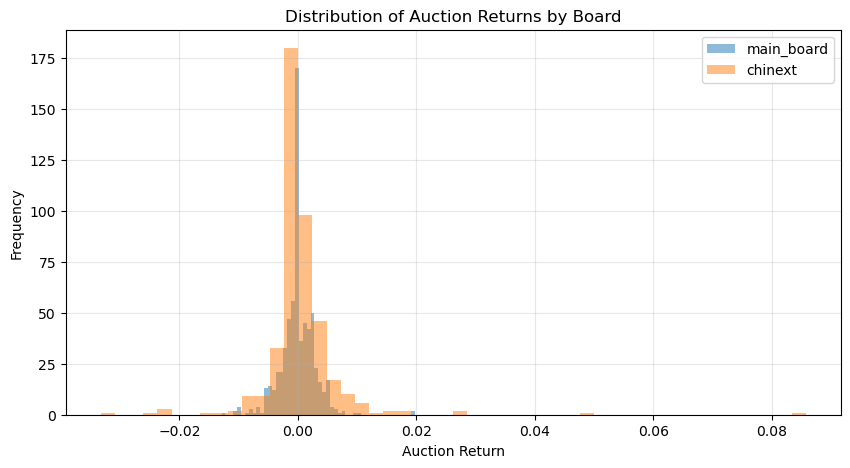

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for board in feature_df["board"].unique():
    data = feature_df.loc[feature_df["board"] == board, "auction_return"].dropna()
    plt.hist(data, bins=50, alpha=0.5, label=board)

plt.title("Distribution of Auction Returns by Board")
plt.xlabel("Auction Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

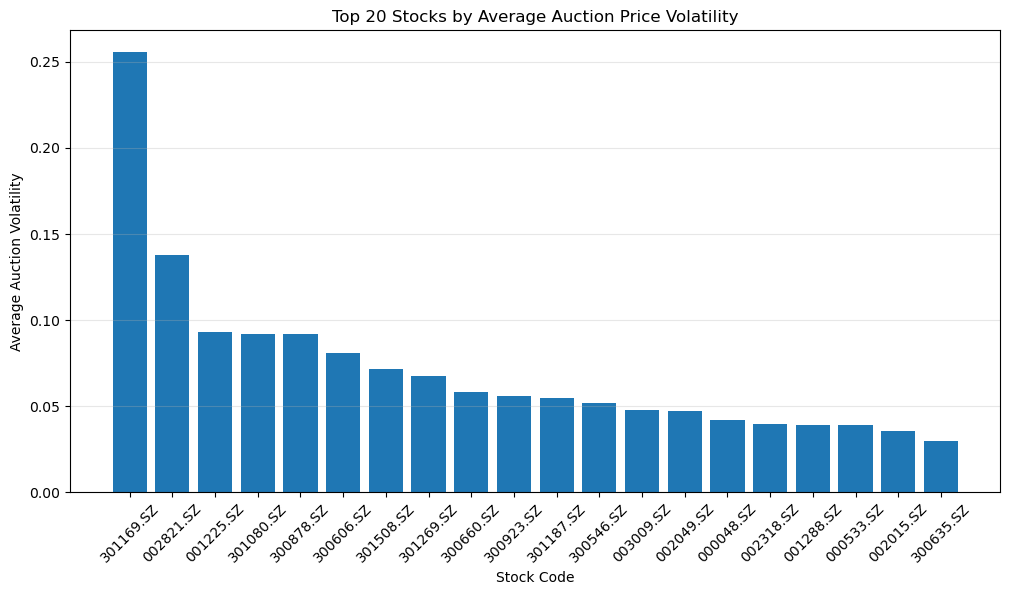

In [132]:
top20 = stock_summary.head(20).copy()

plt.figure(figsize=(12, 6))
plt.bar(top20["code"], top20["avg_volatility"])

plt.title("Top 20 Stocks by Average Auction Price Volatility")
plt.xlabel("Stock Code")
plt.ylabel("Average Auction Volatility")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [133]:
corr_cols = [
    "auction_return",
    "price_range",
    "price_volatility",
    "n_price_changes",
    "n_ticks"
]

if "total_volume" in feature_df.columns:
    corr_cols.append("total_volume")

corr_matrix = feature_df[corr_cols].corr()

corr_matrix

,auction_return,price_range,price_volatility,n_price_changes,n_ticks
auction_return,1.000000,0.148759,0.148759,0.031553,NaN
price_range,0.148759,1.000000,1.000000,0.238438,NaN
price_volatility,0.148759,1.000000,1.000000,0.238438,NaN
n_price_changes,0.031553,0.238438,0.238438,1.000000,NaN
n_ticks,NaN,NaN,NaN,NaN,NaN


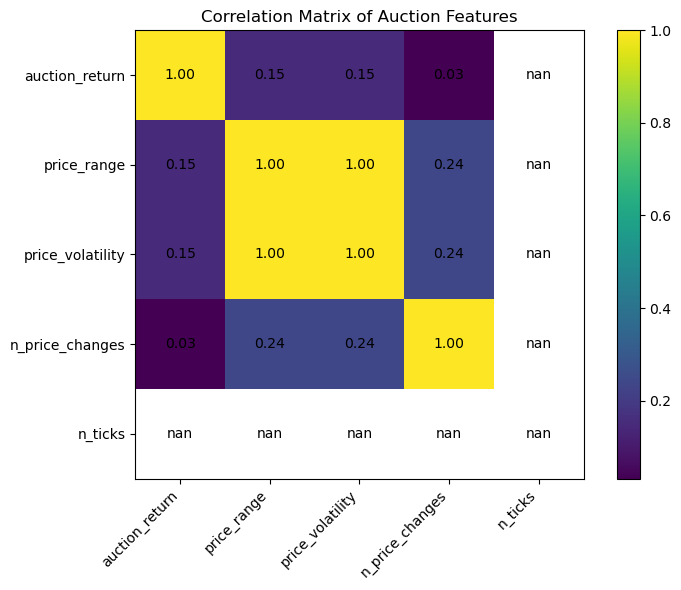

In [134]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Correlation Matrix of Auction Features")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()